In [1]:
import numpy as np
from matplotlib import pyplot as plt
import datetime
import Bayesian_Methods as Bayes
from functools import partial
import sys
import Parameters as Pars
from Full_Par_Method import Parameter_Processing
import Full_Par_Method
from multiprocess import Pool
from dynesty import DynamicNestedSampler, sampler, plotting
from getdist import plots, MCSamples

In [2]:
ndim = 6
par_names = (Pars.psi0[0], Pars.m0[0], Pars.mass_norm[0], Pars.scatter[0], Pars.tau[0], Pars.gamma_inner[0])

In [3]:
def Likelihood_Wrapper(parameters):
    par_names = (Pars.psi0[0], Pars.m0[0], Pars.mass_norm[0], Pars.scatter[0], Pars.tau[0], Pars.gamma_inner[0])
    par_dict = {key: value for key, value in zip(par_names,parameters)}
    t1 = Parameter_Processing(par_dict, load_strain = False)
    Likelihood = t1.Quick_Likelihood()
    return np.log(float(Likelihood))

In [4]:
def Prior_Wrapper(u):
    par_ranges = ((-3.5,10.5,7.5,0,0.1,-1.5),(-1.5,12.5,9.5,1,11,0))
    return Pars.Parameter_Uniform(u,par_ranges[1],par_ranges[0])

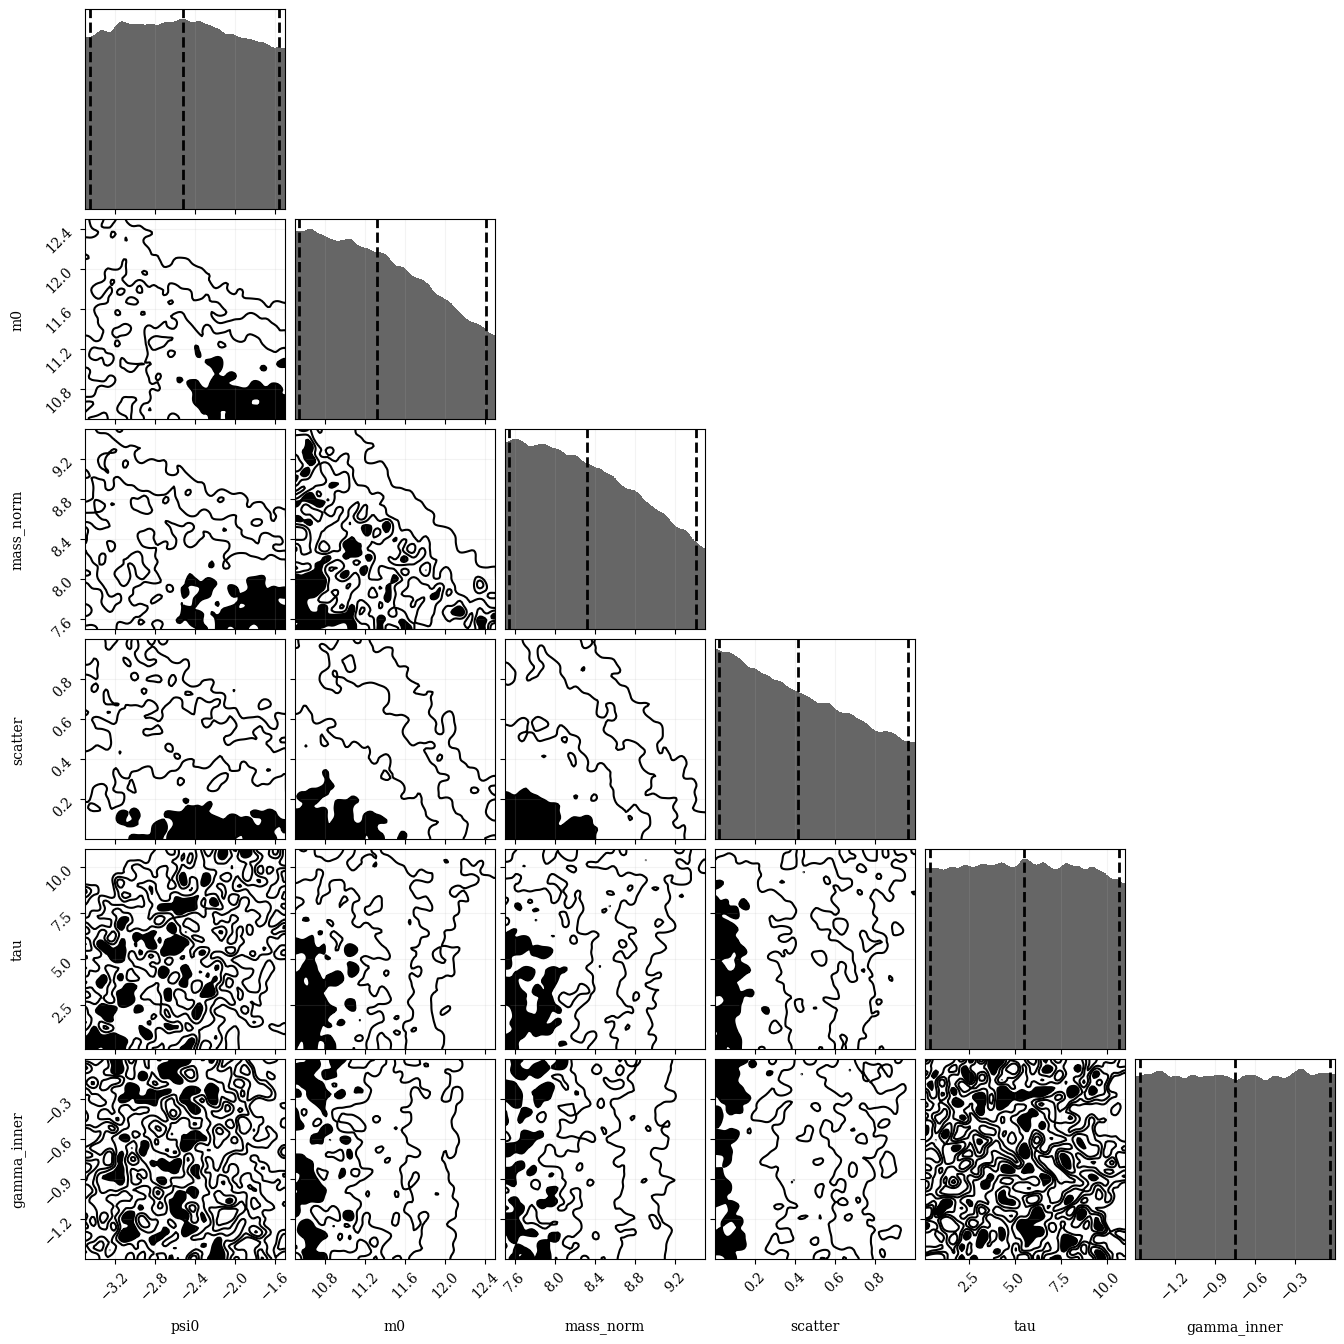

In [6]:
s = sampler.Sampler.restore(f'Dynesty_Samples/{str(par_names)}_Full_Like_Dynamic_Parallel_64_unif_100000_50R')
dresults = s.results
cfig, caxes = plotting.cornerplot(dresults, labels = par_names)
plt.savefig('dynesty_corner_dynamic_sampler_full_100_000_50R.png')